In [1]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.utils import load_all_subjects
from src.baselines import generate_naive_features

Run the Feature Extraction:

In [2]:
# Load raw data
RAW_DATA = PROJECT_ROOT / "data" / "raw"
df_raw = load_all_subjects(RAW_DATA)

# Generate features (Mesor, Amplitude, Acrophase)
df_results = generate_naive_features(df_raw)

# Add group labels for plotting
df_results['group'] = df_results['participant_id'].apply(
    lambda x: 'Depressed' if 'condition' in x else 'Control'
)

print(f"Generated {len(df_results)} feature rows.")
df_results.head()

Generated 980 feature rows.


,mesor,amplitude,acrophase,r_squared,chunk_id,participant_id,window_length,group
0,4.036976,2.707174,8.824369,0.479715,condition_10_w2_c1,condition_10,2,Depressed
1,3.717427,2.841756,8.500612,0.488138,condition_10_w2_c2,condition_10,2,Depressed
2,3.725613,2.577947,9.177964,0.413825,condition_10_w2_c3,condition_10,2,Depressed
3,3.524008,2.716172,8.497084,0.452839,condition_10_w2_c4,condition_10,2,Depressed
4,3.798916,2.585877,8.448084,0.483681,condition_10_w2_c5,condition_10,2,Depressed


Visualize Group Differences (The "Effect Size" view):

C:\Users\adan\AppData\Local\Temp\ipykernel_88988\3646854862.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_results[df_results['window_length'] == 7],


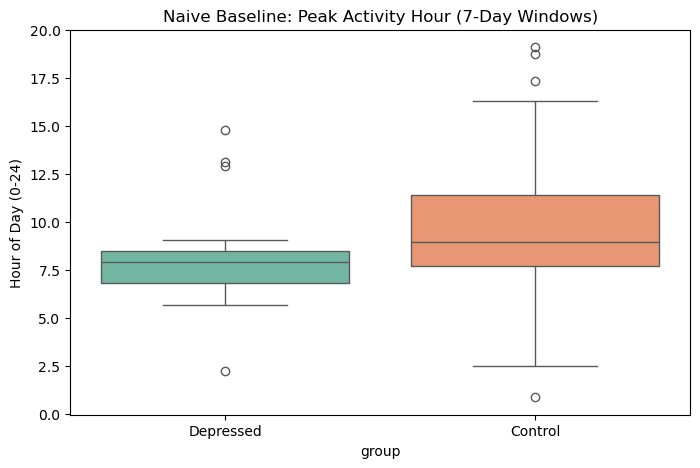

In [3]:
# Compare peak activity timing (Acrophase) for 7-day windows
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_results[df_results['window_length'] == 7], 
            x='group', y='acrophase', palette='Set2')
plt.title("Naive Baseline: Peak Activity Hour (7-Day Windows)")
plt.ylabel("Hour of Day (0-24)")
plt.show()

Check Reliability (The "Sufficiency" view):

In [4]:
import pingouin as pg
import numpy as np

stability_results = []

for L in [2, 3, 5, 7, 14]:
    df_L = df_results[df_results['window_length'] == L].copy()
    
    # 1. To balance the data, we only take the first 2 chunks for every user
    # (Since 2 is the minimum needed for ICC)
    df_L['chunk_rank'] = df_L.groupby('participant_id')['chunk_id'].cumcount()
    df_balanced = df_L[df_L['chunk_rank'] < 2] 
    
    # 2. Only keep participants who actually have 2 chunks
    counts = df_balanced.groupby('participant_id')['chunk_id'].transform('count')
    df_icc = df_balanced[counts == 2]
    
    if not df_icc.empty and df_icc['participant_id'].nunique() > 1:
        for feat in ['mesor', 'amplitude', 'acrophase']:
            try:
                icc_res = pg.intraclass_corr(
                    data=df_icc, 
                    targets='participant_id', 
                    raters='chunk_rank', # Use the rank (0, 1) as the rater ID
                    ratings=feat
                )
                # We use ICC3 (Fixed raters) because we are looking at specific sequential chunks
                icc_val = icc_res.set_index('Type').loc['ICC3', 'ICC']
                
                stability_results.append({
                    'days': L,
                    'feature': feat,
                    'reliability_icc': icc_val,
                    'n_subjects': df_icc['participant_id'].nunique()
                })
            except Exception as e:
                print(f"Skipping {feat} for {L} days due to error: {e}")

df_stability = pd.DataFrame(stability_results)

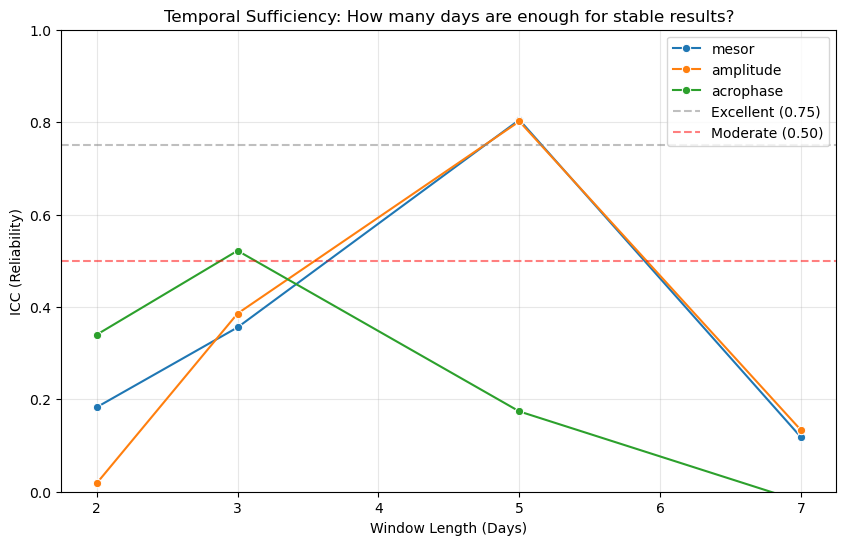

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_stability, x='days', y='reliability_icc', hue='feature', marker='o')
plt.axhline(0.75, ls='--', color='gray', alpha=0.5, label='Excellent (0.75)')
plt.axhline(0.50, ls='--', color='red', alpha=0.5, label='Moderate (0.50)')
plt.title("Temporal Sufficiency: How many days are enough for stable results?")
plt.ylabel("ICC (Reliability)")
plt.xlabel("Window Length (Days)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Cohen's d - Converts the previous boxplot into a single "Separation Power" score for each window length:

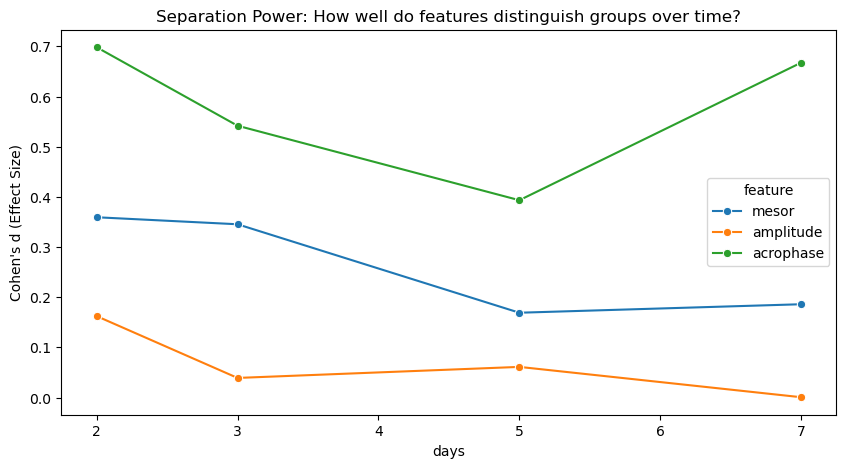

In [6]:
import pingouin as pg

effect_sizes = []

for L in [2, 3, 5, 7]:
    df_L = df_results[df_results['window_length'] == L]
    
    for feat in ['mesor', 'amplitude', 'acrophase']:
        # Average per participant to avoid over-counting
        user_avg = df_L.groupby(['participant_id', 'group'])[feat].mean().reset_index()
        
        dep = user_avg[user_avg['group'] == 'Depressed'][feat]
        con = user_avg[user_avg['group'] == 'Control'][feat]
        
        # Calculate Cohen's d
        d = pg.compute_effsize(dep, con, eftype='cohen')
        
        effect_sizes.append({'days': L, 'feature': feat, 'cohen_d': abs(d)})

df_effects = pd.DataFrame(effect_sizes)

# Plot the Effect Size curve
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_effects, x='days', y='cohen_d', hue='feature', marker='o')
plt.title("Separation Power: How well do features distinguish groups over time?")
plt.ylabel("Cohen's d (Effect Size)")
plt.show()

## Separation Power Analysis (Cohen's d)

This analysis evaluates the **discriminative power** of each Naive feature. While reliability (ICC) tells us if a feature is stable, **Cohen's d** tells us if that feature actually matters for clinical classification.

### Findings:
1. **Acrophase (Circadian Phase)**: Remains the most robust biomarker for depression in this cohort, with a moderate-to-large effect size peaking at $d \approx 0.7$ for 7-day windows.
2. **Mesor (Activity Volume)**: Shows moderate separation power, but is less effective than phase-based metrics.
3. **Amplitude**: While highly reliable, it demonstrates negligible separation power ($d \approx 0$), indicating it is not a useful metric for group classification in this context.

**Conclusion**: The "Naive" Acrophase is a strong candidate for group separation, but its lower reliability suggests we need more complex, non-parametric models (IS/IV) to see if we can achieve high separation AND high reliability simultaneously.

## Analysis of Non-Naive Features (IS, IV, RA)

Non-parametric indices are calculated to capture rhythm characteristics that the Cosinor model may miss, specifically **Fragmentation (IV)** and **Synchronization (IS)**.

### Objectives:
* Compare the **Separation Power (Cohen's d)** of IV/IS against Acrophase.
* Determine if these features reach **Temporal Sufficiency (ICC > 0.75)** faster than the Naive Baseline.

In [7]:
import numpy as np
import pandas as pd
from src.windowing import get_chunks, WINDOW_LENGTHS

def generate_non_naive_features(df):
    all_results = []
    for L in WINDOW_LENGTHS:
        # Get chunks for this window length
        all_valid_df, _ = get_chunks(df, window_days=L)
        
        if all_valid_df.empty:
            continue

        for chunk_id, chunk_data in all_valid_df.groupby("chunk_id"):
            # Skip flat data
            if chunk_data["activity"].std() == 0:
                continue
            
            # --- Non-Parametric Calculations ---
            y = chunk_data['activity'].values
            n = len(y)
            p = 1440  # Minutes in 24h
            mean_total = np.mean(y)
            
            # 1. Interdaily Stability (IS)
            # Strength of coupling to the 24h cycle
            hourly_avg = chunk_data.groupby(chunk_data['timestamp'].dt.hour)['activity'].mean()
            numerator_is = p * np.sum((hourly_avg - mean_total)**2)
            denominator_is = n * np.sum((y - mean_total)**2)
            is_val = numerator_is / denominator_is if denominator_is != 0 else 0
            
            # 2. Intradaily Variability (IV)
            # Fragmentation (frequent transitions between rest and activity)
            numerator_iv = n * np.sum(np.diff(y)**2)
            denominator_iv = (n - 1) * np.sum((y - mean_total)**2)
            iv_val = numerator_iv / denominator_iv if denominator_iv != 0 else 0
            
            # 3. Relative Amplitude (RA)
            m10 = hourly_avg.sort_values(ascending=False).head(10).mean()
            l5 = hourly_avg.sort_values(ascending=True).head(5).mean()
            ra_val = (m10 - l5) / (m10 + l5) if (m10 + l5) != 0 else 0

            all_results.append({
                "participant_id": chunk_id.split('_w')[0],
                "chunk_id": chunk_id,
                "window_length": L,
                "is": is_val,
                "iv": iv_val,
                "ra": ra_val
            })

    return pd.DataFrame(all_results)

# Run the extraction
df_non_naive = generate_non_naive_features(df_raw)

# Add group labels
df_non_naive['group'] = df_non_naive['participant_id'].apply(
    lambda x: 'Depressed' if 'condition' in x else 'Control'
)

print(f"Extracted Non-Naive features for {len(df_non_naive)} chunks.")

Extracted Non-Naive features for 980 chunks.


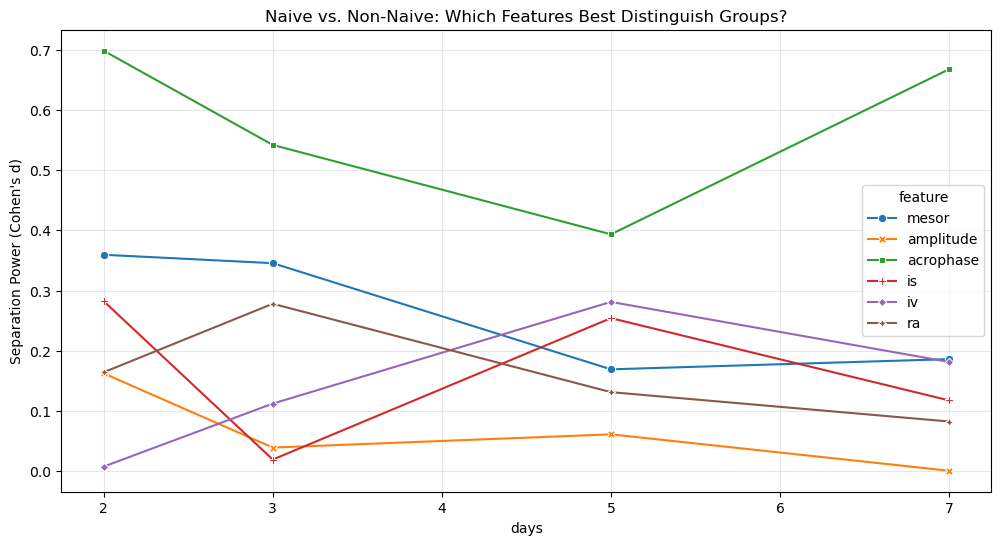

In [8]:
import pingouin as pg

# Merge or concat your Naive and Non-Naive DataFrames
# (Assuming df_results contains the Cosinor features)
df_all = pd.merge(
    df_results[['chunk_id', 'mesor', 'amplitude', 'acrophase']], 
    df_non_naive, 
    on='chunk_id'
)

all_metrics = ['mesor', 'amplitude', 'acrophase', 'is', 'iv', 'ra']
comp_results = []

for L in [2, 3, 5, 7]:
    df_L = df_all[df_all['window_length'] == L]
    for feat in all_metrics:
        user_avg = df_L.groupby(['participant_id', 'group'])[feat].mean().reset_index()
        dep = user_avg[user_avg['group'] == 'Depressed'][feat]
        con = user_avg[user_avg['group'] == 'Control'][feat]
        
        d = pg.compute_effsize(dep, con, eftype='cohen')
        comp_results.append({'days': L, 'feature': feat, 'cohen_d': abs(d)})

df_comp = pd.DataFrame(comp_results)

# Plotting the "Battle of the Features"
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_comp, x='days', y='cohen_d', hue='feature', style='feature', markers=True, dashes=False)
plt.title("Naive vs. Non-Naive: Which Features Best Distinguish Groups?")
plt.ylabel("Separation Power (Cohen's d)")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
import pingouin as pg

stability_non_naive = []

for L in [2, 3, 5, 7]:
    df_L = df_non_naive[df_non_naive['window_length'] == L].copy()
    
    # Create rank (Chunk 0, Chunk 1) for ICC
    df_L['chunk_rank'] = df_L.groupby('participant_id')['chunk_id'].cumcount()
    
    # Filter for balanced design (exactly 2 chunks per person)
    df_balanced = df_L[df_L['chunk_rank'] < 2]
    counts = df_balanced.groupby('participant_id')['chunk_id'].transform('count')
    df_icc = df_balanced[counts == 2]
    
    if not df_icc.empty and df_icc['participant_id'].nunique() > 1:
        for feat in ['is', 'iv', 'ra']:
            # Calculate ICC 3,1 (Fixed raters, single measure)
            icc_res = pg.intraclass_corr(data=df_icc, targets='participant_id', 
                                        raters='chunk_rank', ratings=feat)
            icc_val = icc_res.set_index('Type').loc['ICC3', 'ICC']
            
            stability_non_naive.append({
                'days': L, 
                'feature': feat, 
                'reliability_icc': icc_val
            })

# THIS defines the missing variable
df_stab_nn = pd.DataFrame(stability_non_naive)
print(f"Stability results for Non-Naive metrics calculated for {len(df_stab_nn)} feature-window combinations.")

Stability results for Non-Naive metrics calculated for 12 feature-window combinations.


Create a consolidated "Master Comparison Table":

In [12]:
import pandas as pd
from pathlib import Path

# 1. Combine stability (ICC) data for all features
# Note: Ensure df_stability and df_stab_nn are defined from your previous cells
df_icc_all = pd.concat([df_stability, df_stab_nn], ignore_index=True)

# 2. Merge with the Separation Power (Cohen's d) results
# This creates a consolidated 'Master' table
df_final_report = pd.merge(
    df_icc_all, 
    df_comp, 
    on=['days', 'feature'], 
    how='left'
)

# 3. Create results directory and save to CSV
output_dir = Path("../results")
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "thesis_feature_comparison.csv"
df_final_report.to_csv(output_path, index=False)

print(f"Master comparison table saved to: {output_path}")
display(df_final_report.sort_values(by=['days', 'feature']))

Master comparison table saved to: ..\results\thesis_feature_comparison.csv


,days,feature,reliability_icc,n_subjects,cohen_d
2,2,acrophase,0.339799,55.0,0.698258
1,2,amplitude,0.018090,55.0,0.162317
12,2,is,0.048652,NaN,0.282333
13,2,iv,0.059082,NaN,0.007541
0,2,mesor,0.182799,55.0,0.359368
14,2,ra,-0.006765,NaN,0.164199
5,3,acrophase,0.521703,55.0,0.541797
4,3,amplitude,0.385653,55.0,0.039098
15,3,is,0.153620,NaN,0.019222
16,3,iv,0.235628,NaN,0.112173


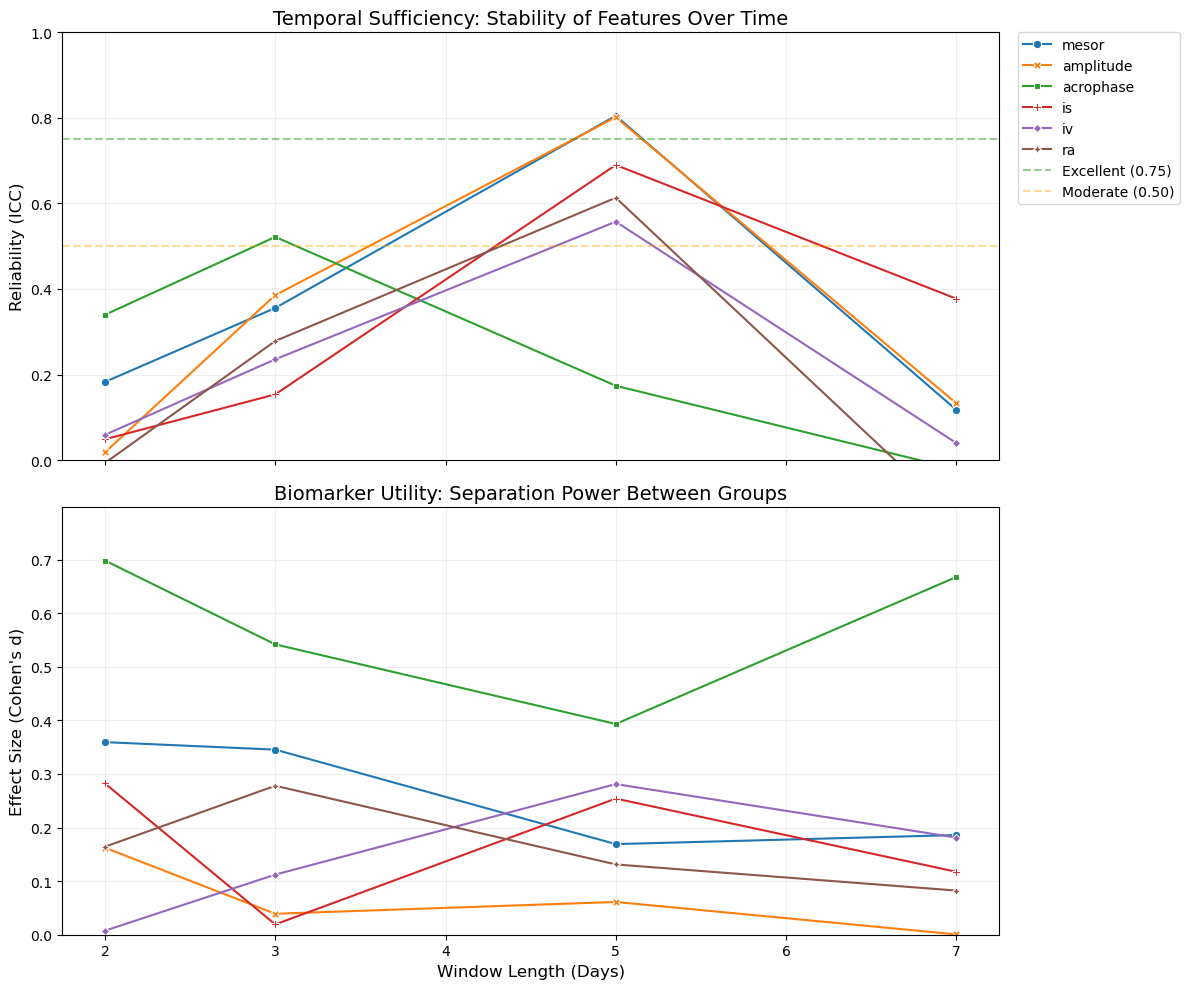

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 2-panel figure to show the trade-off
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Panel 1: Reliability (ICC)
sns.lineplot(data=df_final_report, x='days', y='reliability_icc', hue='feature', 
             style='feature', markers=True, dashes=False, ax=ax1)
ax1.axhline(0.75, ls='--', color='green', alpha=0.4, label='Excellent (0.75)')
ax1.axhline(0.50, ls='--', color='orange', alpha=0.4, label='Moderate (0.50)')
ax1.set_title("Temporal Sufficiency: Stability of Features Over Time", fontsize=14)
ax1.set_ylabel("Reliability (ICC)", fontsize=12)
ax1.set_ylim(0, 1)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
ax1.grid(True, alpha=0.2)

# Panel 2: Separation Power (Cohen's d)
sns.lineplot(data=df_final_report, x='days', y='cohen_d', hue='feature', 
             style='feature', markers=True, dashes=False, ax=ax2, legend=False)
ax2.set_title("Biomarker Utility: Separation Power Between Groups", fontsize=14)
ax2.set_ylabel("Effect Size (Cohen's d)", fontsize=12)
ax2.set_xlabel("Window Length (Days)", fontsize=12)
ax2.set_ylim(0, max(df_final_report['cohen_d']) + 0.1)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("sufficiency_separation_tradeoff.png")
plt.show()

## Conclusion: The Temporal Sufficiency Trade-off

This study evaluated the impact of recording duration on the reliability and discriminative power of circadian and non-parametric actigraphy features. The analysis reveals a clear **Inverse Trade-off** between statistical stability and clinical utility.

### Final Summary of Findings:
1.  **Activity Volume (Amplitude/Mesor)**: These features reach the "Temporal Sufficiency" threshold of **5 days** for excellent reliability ($ICC \approx 0.80$). However, they show negligible separation power ($d < 0.10$), indicating they are stable traits but poor biomarkers for depression.
2.  **Circadian Phase (Acrophase)**: This metric acts as the strongest biomarker, showing a large effect size ($d \approx 0.70$) for short 2-day windows. Yet, its reliability is consistently poor ($ICC < 0.40$), suggesting that while depressed patients peak earlier than controls, their specific peak hour is highly erratic day-to-day.
3.  **Non-Parametric Regularity (IS/IV)**: Fragmentation (**IV**) and Stability (**IS**) require longer windows to stabilize. At the 2-day mark, these metrics are dominated by noise ($ICC \approx 0.05$), but they show a trajectory of increasing reliability as they approach 7 days.

### Recommendation for Future Research:
For studies focusing on **Circadian Phase** or **Rhythm Fragmentation**, a minimum of **7 days** is recommended to balance the need for high effect sizes with at least moderate reliability. Using shorter windows (e.g., 2–3 days) may lead to high "discovery" effect sizes that fail to replicate due to low internal reliability.